In [ ]:
# Implementation of ry_feature_map suitable for a quantum kernel
from qiskit import QuantumCircuit
import numpy as np

def ry_feature_map(n_qubits, data, entanglement="ring"):
    """
    Build a feature map that encodes `data` using Ry rotations and applies
    a configurable entanglement pattern using CNOT gates.

    Parameters:
    - n_qubits: int, number of qubits (expected length of `data`)
    - data: iterable of real values with length `n_qubits`
    - entanglement: 'chain' | 'ring' | 'all_to_all'

    Returns:
    - QuantumCircuit (no measurements)
    """
    arr = np.asarray(data, dtype=float).ravel()
    if arr.size != n_qubits:
        raise ValueError(f"data must have length equal to n_qubits ({n_qubits}); got {arr.size}")

    qc = QuantumCircuit(n_qubits)

    # Encode each feature with Ry on the corresponding qubit
    for q in range(n_qubits):
        qc.ry(arr[q], q)

    ent = (entanglement or "").lower()
    if ent == "chain":
        for i in range(n_qubits - 1):
            qc.cx(i, i + 1)
    elif ent == "ring":
        for i in range(n_qubits - 1):
            qc.cx(i, i + 1)
        if n_qubits > 1:
            qc.cx(n_qubits - 1, 0)
    elif ent == "all_to_all":
        for i in range(n_qubits):
            for j in range(i + 1, n_qubits):
                qc.cx(i, j)
    else:
        raise ValueError("Unsupported entanglement pattern. Choose 'chain', 'ring' or 'all_to_all'.")

    return qc

In [ ]:
def phase_feature_map(n_qubits, data, entanglement="ring"):
    """
    Build a feature map that encodes `data` as Z-phase rotations (Rz) on each qubit
    after preparing equal superposition states with Hadamards, and applies
    configurable entanglement using controlled-Z (CZ) gates. The circuit is
    suitable for quantum kernel evaluation (no measurements).

    Parameters:
    - n_qubits: int, number of qubits (expected length of `data`)
    - data: iterable of real values with length `n_qubits`
    - entanglement: 'chain' | 'ring' | 'all_to_all'

    Returns:
    - QuantumCircuit (no measurements)
    """
    arr = np.asarray(data, dtype=float).ravel()
    if arr.size != n_qubits:
        raise ValueError(f"data must have length equal to n_qubits ({n_qubits}); got {arr.size}")

    qc = QuantumCircuit(n_qubits)

    # Prepare |+> states on all qubits
    for q in range(n_qubits):
        qc.h(q)

    # Encode each feature as a Z-phase (Rz) on the corresponding qubit
    for q in range(n_qubits):
        qc.rz(arr[q], q)

    ent = (entanglement or "").lower()
    if ent == "chain":
        for i in range(n_qubits - 1):
            qc.cz(i, i + 1)
    elif ent == "ring":
        for i in range(n_qubits - 1):
            qc.cz(i, i + 1)
        if n_qubits > 1:
            qc.cz(n_qubits - 1, 0)
    elif ent == "all_to_all":
        for i in range(n_qubits):
            for j in range(i + 1, n_qubits):
                qc.cz(i, j)
    else:
        raise ValueError("Unsupported entanglement pattern. Choose 'chain', 'ring' or 'all_to_all'.")

    return qc

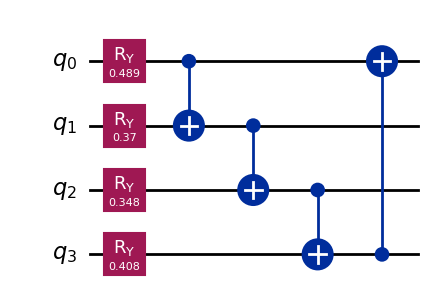

In [2]:
# Example usage: construct and visualize a circuit for 4 qubits
from qiskit.visualization import circuit_drawer

# Example data (must have length equal to n_qubits)
data = [0.48854, 0.36986, 0.34778, 0.40850]
qc = ry_feature_map(4, data, entanglement="ring")

# Display the circuit in the notebook (uses matplotlib if available)
qc.draw(output="mpl")